# 실습 4: 얼굴 비교 (Face Comparison)

## 학습 목표
- Amazon Rekognition의 `compare_faces` API로 두 얼굴의 유사도를 비교합니다.
- SimilarityThreshold를 조정하여 매칭 기준을 이해합니다.

## API 개요
`compare_faces`는 소스(기준) 이미지의 얼굴과 타겟 이미지의 얼굴을 비교합니다.
- **SourceImage**: 기준이 되는 얼굴 이미지
- **TargetImage**: 비교할 얼굴 이미지
- **SimilarityThreshold**: 매칭으로 판단할 최소 유사도 (기본 80%)
- **반환값**:
  - `FaceMatches`: 유사도 임계값 이상인 얼굴 목록
  - `UnmatchedFaces`: 임계값 미만인 얼굴 목록
  - `Similarity`: 각 매칭 얼굴의 유사도 (0~100)


In [9]:
import boto3
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ✅ [제공 코드]
rekognition = boto3.client('rekognition', region_name='ap-northeast-2')
IMAGE_DIR = './images/'

def load_image_bytes(path):
    with open(path, 'rb') as f:
        return f.read()

source_path = os.path.join(IMAGE_DIR, 'lab04_source.jpg')
source_bytes = load_image_bytes(source_path)
target_path  = os.path.join(IMAGE_DIR, 'lab04_target.jpg')
target_bytes = load_image_bytes(target_path)
print("이미지 로드 완료")

이미지 로드 완료


## ✏️ TODO 1: compare_faces API 호출

두 이미지의 얼굴을 비교하세요. SimilarityThreshold는 80으로 설정하세요.


In [6]:
# ✏️ TODO 1: compare_faces API를 호출하세요
response = rekognition.compare_faces( # ← compare_faces
    SourceImage={'Bytes': source_bytes}, # ← source_bytes
    TargetImage={'Bytes': target_bytes}, # ← target_bytes
    SimilarityThreshold=80    # ← 80
)

matches   = response['FaceMatches']
unmatched = response['UnmatchedFaces']
print(f"매칭된 얼굴: {len(matches)}개")
print(f"매칭 안 된 얼굴: {len(unmatched)}개")

매칭된 얼굴: 1개
매칭 안 된 얼굴: 0개


## ✏️ TODO 2: 비교 결과 출력

매칭된 얼굴의 유사도와 위치 정보를 출력하세요.


In [7]:
# ✏️ TODO 2: 비교 결과를 출력하세요
if len(matches) > 0:
    print("\n✅ 동일 인물로 판정된 얼굴:")
    print("-" * 40)
    for i, match in enumerate(matches):
        similarity = match['Similarity']  # ← 'Similarity' 
        face       = match['Face']  # ← 'Face' 
        confidence = face['Confidence']   # ← 'Confidence' 
        print(f"  얼굴 #{i+1}: 유사도 {similarity:.1f}%, 탐지 신뢰도 {confidence:.1f}%")
else:
    print("\n❌ 동일 인물이 발견되지 않았습니다.")


✅ 동일 인물로 판정된 얼굴:
----------------------------------------
  얼굴 #1: 유사도 100.0%, 탐지 신뢰도 100.0%


## ✏️ TODO 3: 두 이미지 나란히 시각화

소스와 타겟 이미지를 나란히 표시하고, 결과를 제목에 반영하세요.


/tmp/ipykernel_2092/2387878679.py:31: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2092/2387878679.py:31: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2092/2387878679.py:31: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2092/2387878679.py:31: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2092/2387878679.py:31: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2092/2387878679.py:31: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2092/2387878679.py:31: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


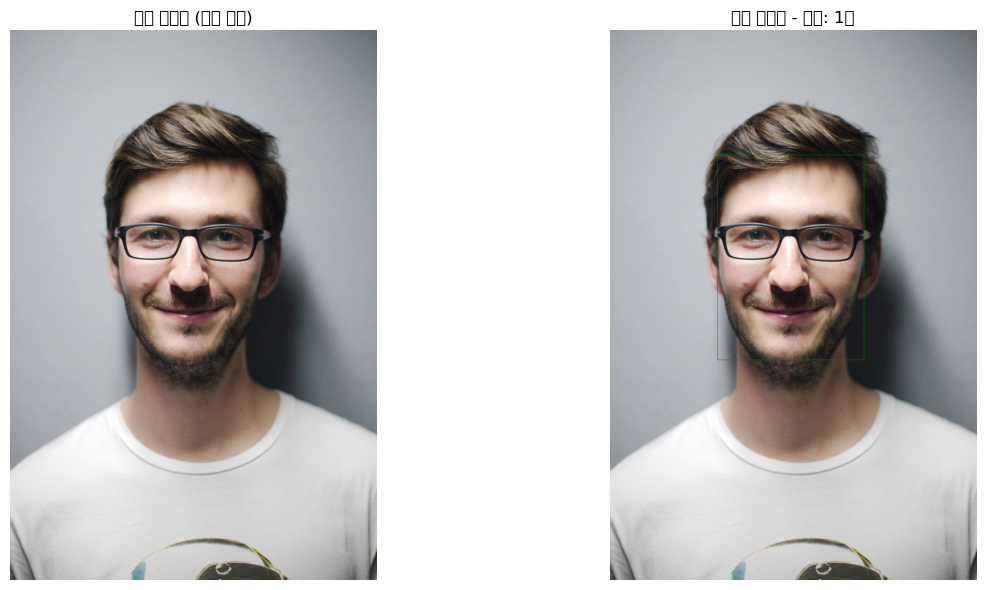

In [8]:
# ✏️ TODO 3: 두 이미지를 나란히 표시하세요

# 시각화 틀 잡기
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 소스 이미지(기준이 되는 얼굴 이미지) 표시
axes[0].imshow(Image.open(source_path))
axes[0].set_title('소스 이미지 (기준 얼굴)')
axes[0].axis('off')

# 타겟 이미지에 매칭 결과 BoundingBox 표시
target_img = Image.open(target_path)
draw = ImageDraw.Draw(target_img)
tw, th = target_img.size

# 결과값에서 BoundingBox 값을 반환받아, 이를 실제 이미지 크기(tw, th)와 곱해 물리적인 픽셀 위치로 변환
for match in matches:
    box = match['Face']['BoundingBox']
    # ← 픽셀 좌표 계산 (Lab 1, 3에서 배운 방법 사용)
    left   = box['Left'] * tw
    top    = box['Top'] * th
    right  = left + box['Width'] * tw
    bottom = top  + box['Height'] * th
    draw.rectangle([left, top, right, bottom], outline='green', width=4)
    draw.text((left, top-20), f"유사도: {match['Similarity']:.1f}%", fill='green')

result_text = f"매칭: {len(matches)}개" if len(matches) > 0 else "매칭 없음"
axes[1].imshow(target_img)
axes[1].set_title(f'타겟 이미지 - {result_text}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 💡 심화 도전
1. SimilarityThreshold를 90, 70, 50으로 바꿔보면 결과가 어떻게 달라지나요?
2. 다른 사람의 사진으로 테스트했을 때 Similarity 값은 어느 정도인가요?
3. 동일 인물의 정면/측면 사진을 비교해 Similarity를 측정해보세요.
